In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("hr_attrition_flat.csv")

In [3]:
df.head()

,EmployeeNumber,Age,Gender,MaritalStatus,Education,EducationField,NumCompaniesWorked,Over18,DistanceFromHome,Attrition,...,BusinessTravel,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TrainingTimesLastYear
0,1,41,Female,Single,2,Life Sciences,8,Y,1,Yes,...,Travel_Rarely,2,1,1,8,6,4,0,5,0
1,2,49,Male,Married,1,Life Sciences,1,Y,8,No,...,Travel_Frequently,3,4,3,10,10,7,1,7,3
2,4,37,Male,Single,2,Other,6,Y,2,Yes,...,Travel_Rarely,4,2,3,7,0,0,0,0,3
3,5,33,Female,Married,4,Life Sciences,1,Y,3,No,...,Travel_Frequently,4,3,3,8,8,7,3,0,3
4,7,27,Male,Married,1,Medical,9,Y,2,No,...,Travel_Rarely,1,4,3,6,2,2,2,2,3


In [4]:
df.shape

(1470, 35)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeNumber            1470 non-null   int64 
 1   Age                       1470 non-null   int64 
 2   Gender                    1470 non-null   object
 3   MaritalStatus             1470 non-null   object
 4   Education                 1470 non-null   int64 
 5   EducationField            1470 non-null   object
 6   NumCompaniesWorked        1470 non-null   int64 
 7   Over18                    1470 non-null   object
 8   DistanceFromHome          1470 non-null   int64 
 9   Attrition                 1470 non-null   object
 10  PerformanceRating         1470 non-null   int64 
 11  EmployeeCount             1470 non-null   int64 
 12  MonthlyIncome             1470 non-null   int64 
 13  MonthlyRate               1470 non-null   int64 
 14  DailyRate               

In [6]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [7]:
df['Attrition'].value_counts(normalize=True)*100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.duplicated().sum()

np.int64(0)

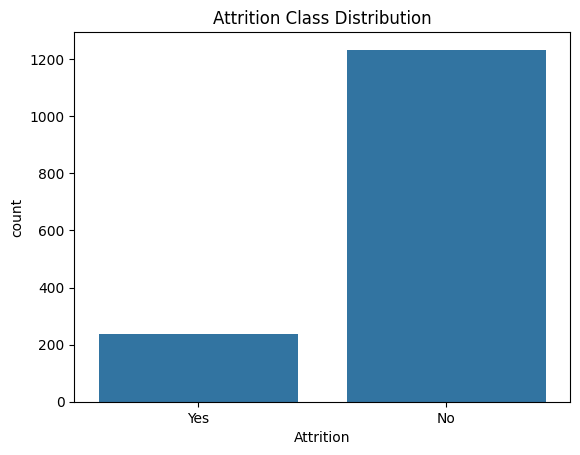

In [10]:
sns.countplot(x="Attrition" , data=df)
plt.title('Attrition Class Distribution')
plt.show()

Confirms the ~84/16 split visually. 

note: "Significant class imbalance — will need to account for this in model evaluation (F1/recall over accuracy) and possibly in training (class weights or SMOTE)."

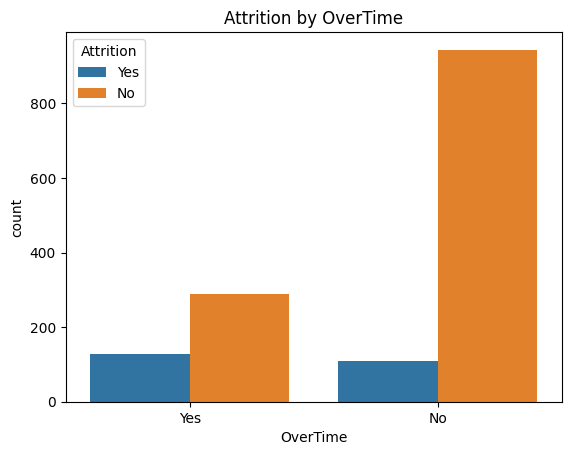

In [11]:
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title('Attrition by OverTime')
plt.show()

This is a strong signal. Employees who work overtime show a much higher proportion of attrition relative to their group size — roughly a third of the OverTime=Yes group left, vs a small fraction of OverTime=No. 

Note: "OverTime is a strong candidate predictor — proportionally, employees working overtime attrite far more often than those who don't."

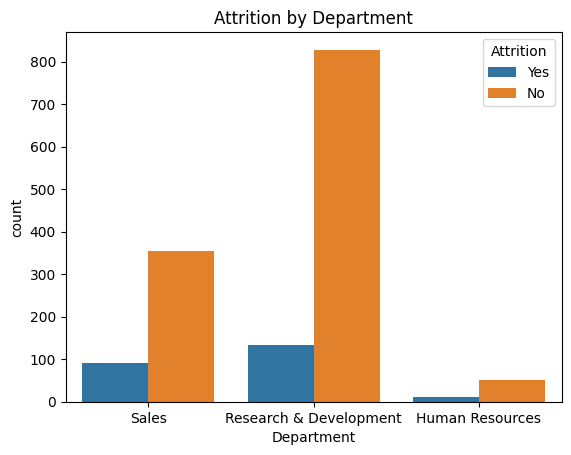

In [12]:
sns.countplot(x='Department', hue='Attrition', data=df)
plt.title('Attrition by Department')
plt.show()

Research & Development has the most employees and the most attrition in raw numbers, but check the rate, not just the count — Sales has ~90/440 ≈ 20% attrition, R&D has ~130/950 ≈ 14%, HR is small but worth checking its rate too. Raw counts can be misleading with unequal group sizes — mention this nuance in your markdown, it shows analytical maturity.

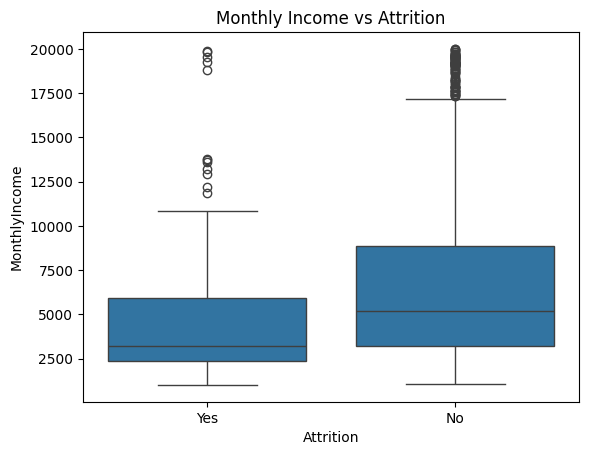

In [13]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Monthly Income vs Attrition')
plt.show()

employees who left have a noticeably lower median income and a tighter, lower distribution overall compared to those who stayed. 

Note: "Lower income is associated with higher attrition — consistent with common HR attrition literature

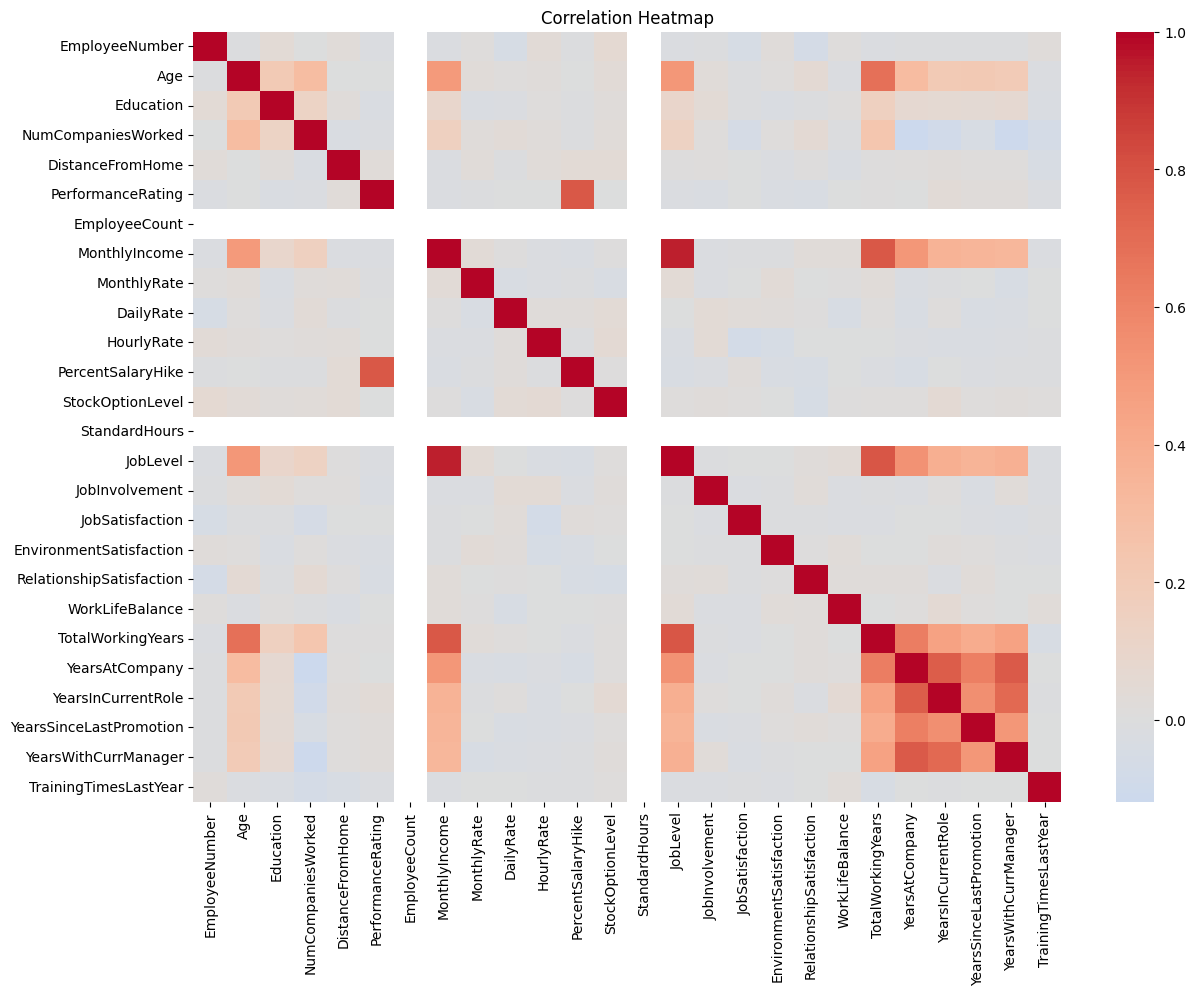

In [14]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager are all strongly correlated with each other this is multicollinearity.someone with a long tenure naturally has more years in their current role, with their current manager, etc

JobLevel, MonthlyIncome, TotalWorkingYears, Age also correlate strongly with each other — expected, since seniority drives pay and experience.

PercentSalaryHike and PerformanceRating show a distinct, isolated strong correlation — makes sense (better performance → bigger hike), but this pair is separate from everything else.

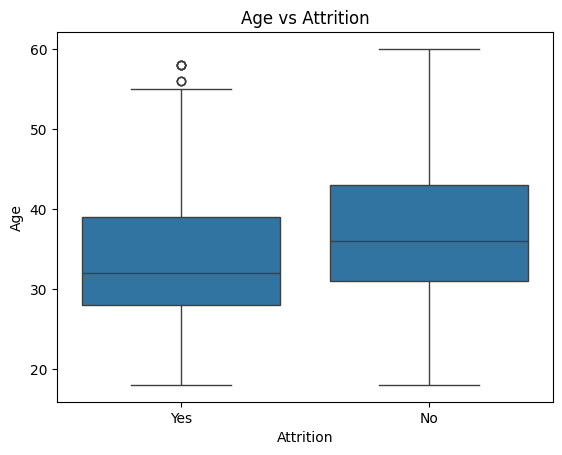

In [15]:
sns.boxplot(x='Attrition', y='Age', data=df)
plt.title('Age vs Attrition')
plt.show()

Employees who left (Yes) skew younger — median age around 32 vs 36 for those who stayed, with a tighter, lower spread. 

Note: "Younger employees show higher attrition — consistent with early-career job-hopping patterns."

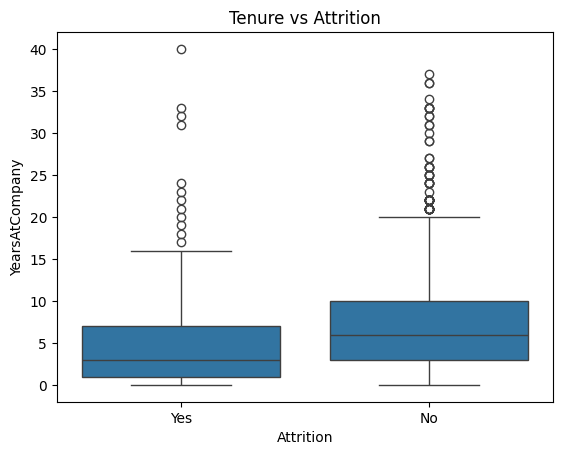

In [16]:
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title('Tenure vs Attrition')
plt.show()

Similarly, employees who left have much lower YearsAtCompany — median around 3 years vs 6 for those who stayed, and far fewer high-tenure outliers. 

Note: "Early-tenure employees are more likely to leave — suggests attrition risk is highest in the first few years, tapering off with long-term employees."

In [17]:
df = df.drop(columns=['Over18', 'EmployeeCount', 'StandardHours'])

In [18]:
df = df.drop(columns=['EmployeeNumber'])

In [19]:
from sklearn.preprocessing import LabelEncoder

Attrition_le = LabelEncoder()
df['Attrition'] = Attrition_le.fit_transform(df['Attrition'])

In [20]:
Gender_le = LabelEncoder()
df["Gender"] = Gender_le.fit_transform(df["Gender"])

In [21]:
OverTime_le = LabelEncoder()
df["OverTime"] = OverTime_le.fit_transform(df["OverTime"])

In [22]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols

['MaritalStatus', 'EducationField', 'Department', 'JobRole', 'BusinessTravel']

In [23]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [24]:
df.head()

,Age,Gender,Education,NumCompaniesWorked,DistanceFromHome,Attrition,PerformanceRating,MonthlyIncome,MonthlyRate,DailyRate,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely
0,41,0,2,8,1,1,3,5993,19479,1102,...,False,False,False,False,False,False,True,False,False,True
1,49,1,1,1,8,0,4,5130,24907,279,...,False,False,False,False,False,True,False,False,True,False
2,37,1,2,6,2,1,3,2090,2396,1373,...,False,True,False,False,False,False,False,False,False,True
3,33,0,4,1,3,0,3,2909,23159,1392,...,False,False,False,False,False,True,False,False,True,False
4,27,1,1,9,2,0,3,3468,16632,591,...,False,True,False,False,False,False,False,False,False,True


In [25]:
x = df.drop(columns="Attrition")
y = df["Attrition"]

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [28]:
x_train.shape , x_test.shape

((1176, 44), (294, 44))

In [29]:
y_train.value_counts(normalize=True) , y_test.value_counts(normalize=True)

(Attrition
 0    0.838435
 1    0.161565
 Name: proportion, dtype: float64,
 Attrition
 0    0.840136
 1    0.159864
 Name: proportion, dtype: float64)

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
numeric_cols = ['Age', 'DistanceFromHome', 'MonthlyIncome', 'MonthlyRate', 
                 'DailyRate', 'HourlyRate', 'PercentSalaryHike', 
                 'NumCompaniesWorked', 'TotalWorkingYears', 'YearsAtCompany',
                 'YearsInCurrentRole', 'YearsSinceLastPromotion', 
                 'YearsWithCurrManager', 'TrainingTimesLastYear']

scaler = StandardScaler()

x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

x_train_scaled[numeric_cols] = scaler.fit_transform(x_train[numeric_cols])
x_test_scaled[numeric_cols] = scaler.transform(x_test[numeric_cols])

In [32]:
x_train_scaled[numeric_cols].describe()

,Age,DistanceFromHome,MonthlyIncome,MonthlyRate,DailyRate,HourlyRate,PercentSalaryHike,NumCompaniesWorked,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TrainingTimesLastYear
count,1.176000e+03,1.176000e+03,1.176000e+03,1.176000e+03,1.176000e+03,1.176000e+03,1.176000e+03,1.176000e+03,1.176000e+03,1.176000e+03,1.176000e+03,1.176000e+03,1.176000e+03,1.176000e+03
mean,-4.229421e-17,-4.682573e-17,-7.930164e-17,7.552538e-18,1.359457e-16,-3.776269e-18,-1.480297e-16,-5.739929e-17,-7.288199e-17,-1.586033e-17,5.588878e-17,-9.667248e-17,7.854639e-17,3.625218e-17
std,1.000425e+00,1.000425e+00,1.000425e+00,1.000425e+00,1.000425e+00,1.000425e+00,1.000425e+00,1.000425e+00,1.000425e+00,1.000425e+00,1.000425e+00,1.000425e+00,1.000425e+00,1.000425e+00
min,-2.070831e+00,-1.022219e+00,-1.189876e+00,-1.710240e+00,-1.747373e+00,-1.743216e+00,-1.152896e+00,-1.083704e+00,-1.457385e+00,-1.158801e+00,-1.185905e+00,-6.791650e-01,-1.177687e+00,-2.198092e+00
25%,-7.628207e-01,-8.999145e-01,-7.730452e-01,-8.817020e-01,-8.381548e-01,-8.593318e-01,-8.809738e-01,-6.812931e-01,-6.879643e-01,-6.657059e-01,-6.253649e-01,-6.791650e-01,-6.164065e-01,-6.053894e-01
50%,-1.088155e-01,-2.883928e-01,-3.309550e-01,-2.397821e-03,-1.119603e-02,2.455234e-02,-3.371285e-01,-2.788819e-01,-1.750171e-01,-3.369760e-01,-3.450946e-01,-3.680244e-01,-3.357661e-01,1.909617e-01
75%,6.541906e-01,5.677376e-01,4.033900e-01,8.874422e-01,8.799502e-01,8.593318e-01,7.505619e-01,5.259405e-01,4.661669e-01,4.848486e-01,7.759863e-01,2.542569e-01,7.867953e-01,1.909617e-01
max,2.507205e+00,2.402303e+00,2.886856e+00,1.753707e+00,1.732459e+00,1.694111e+00,2.654020e+00,2.537997e+00,3.672087e+00,4.922701e+00,3.578689e+00,3.987945e+00,3.593199e+00,2.580015e+00


## Modeling

Since this is a binary classification problem with significant class imbalance (~84% No / ~16% Yes), 
three models are compared: Logistic Regression, Random Forest, and Gradient Boosting. 
`class_weight='balanced'` (or `sample_weight` for Gradient Boosting) is used to address the imbalance, 
and Recall on the minority class (Attrition=Yes) is prioritized over raw accuracy, since failing to 
identify an at-risk employee is more costly than a false alarm in an HR retention context.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [34]:
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(x_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [35]:
log_reg.score(x_train_scaled, y_train)*100 , log_reg.score(x_test_scaled, y_test)*100

(78.06122448979592, 75.51020408163265)

In [36]:
y_pred = log_reg.predict(x_test_scaled)
y_pred_prob = log_reg.predict_proba(x_test_scaled)[:, 1]

In [37]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294

ROC-AUC: 0.8036867947282281
[[191  56]
 [ 16  31]]


In [39]:
from sklearn.ensemble import RandomForestClassifier

In [40]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=200, max_depth=8, min_samples_leaf=5)
rf.fit(x_train_scaled , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [41]:
rf.score(x_train_scaled, y_train)*100 , rf.score(x_test_scaled, y_test)*100

(96.1734693877551, 82.6530612244898)

In [42]:
y_pred_rf = rf.predict(x_test_scaled)
y_pred_prob_rf = rf.predict_proba(x_test_scaled)[:, 1]

In [43]:
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob_rf))
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       247
           1       0.44      0.34      0.39        47

    accuracy                           0.83       294
   macro avg       0.66      0.63      0.64       294
weighted avg       0.81      0.83      0.82       294

ROC-AUC: 0.7827547592385218
[[227  20]
 [ 31  16]]


In [44]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

In [45]:
gb = GradientBoostingClassifier(random_state=42)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
gb.fit(x_train_scaled, y_train, sample_weight=sample_weights)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [46]:
gb.score(x_train_scaled, y_train)*100 , gb.score(x_test_scaled, y_test)*100

(94.89795918367348, 80.27210884353741)

In [47]:
y_pred_gb = gb.predict(x_test_scaled)
y_pred_proba_gb = gb.predict_proba(x_test_scaled)[:, 1]

In [48]:
print("=== Gradient Boosting ===")
print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_gb))
print(confusion_matrix(y_test, y_pred_gb))

=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       247
           1       0.40      0.47      0.43        47

    accuracy                           0.80       294
   macro avg       0.65      0.67      0.66       294
weighted avg       0.82      0.80      0.81       294

ROC-AUC: 0.7786200361788266
[[214  33]
 [ 25  22]]


## Model Comparison

| Model | Recall (Yes) | Precision (Yes) | ROC-AUC | Train Accuracy |
|---|---|---|---|---|
| Logistic Regression | 0.66 | 0.36 | 0.80 | 78.1% |
| Random Forest (tuned) | 0.34 | 0.44 | 0.78 | 96.2% |
| Gradient Boosting (weighted) | 0.47 | 0.40 | 0.78 | 94.9% |

Despite being the simplest model, Logistic Regression outperformed both ensemble methods on 
Recall and ROC-AUC, suggesting the attrition drivers in this dataset are largely linear/additive 
in nature. Random Forest and Gradient Boosting required explicit imbalance correction and tuning 
to achieve competitive results, and even then trailed Logistic Regression on Recall — the priority 
metric for this HR use case.

**Logistic Regression is selected as the final model.**

In [49]:
from sklearn.metrics import precision_recall_curve

In [50]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)

for t in [0.5, 0.4, 0.35, 0.3, 0.25]:
    y_pred_t = (y_pred_prob >= t).astype(int)
    print(f"\n--- Threshold: {t} ---")
    print(classification_report(y_test, y_pred_t))


--- Threshold: 0.5 ---
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294


--- Threshold: 0.4 ---
              precision    recall  f1-score   support

           0       0.95      0.72      0.82       247
           1       0.35      0.81      0.49        47

    accuracy                           0.73       294
   macro avg       0.65      0.76      0.65       294
weighted avg       0.86      0.73      0.77       294


--- Threshold: 0.35 ---
              precision    recall  f1-score   support

           0       0.95      0.66      0.78       247
           1       0.31      0.81      0.45        47

    accuracy                           0.68       294
   macro avg       0.63      0.73      0.61       294
w

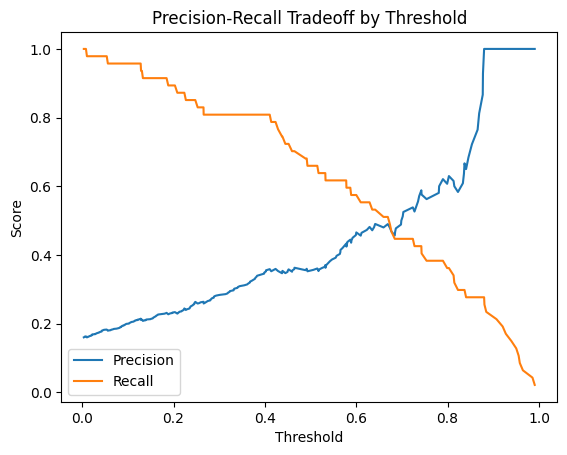

In [51]:
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff by Threshold')
plt.legend()
plt.show()

In [52]:
final_threshold = 0.4
y_pred_final = (y_pred_prob >= final_threshold).astype(int)

print(classification_report(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.95      0.72      0.82       247
           1       0.35      0.81      0.49        47

    accuracy                           0.73       294
   macro avg       0.65      0.76      0.65       294
weighted avg       0.86      0.73      0.77       294

[[177  70]
 [  9  38]]


The default 0.5 threshold missed a significant portion of actual attrition cases. By lowering the 
classification threshold to 0.4, Recall improved from 66% to 81%, at an acceptable precision 
tradeoff. This threshold was chosen deliberately: in an HR retention context, failing to flag an 
at-risk employee (false negative) is more costly than a false alarm (false positive).

In [53]:
coefficients = pd.DataFrame({
    'Feature': x_train_scaled.columns,
    'Coefficient': log_reg.coef_[0]
})

In [54]:
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values('Abs_Coefficient', ascending=False)

print(coefficients.head(15))

                              Feature  Coefficient  Abs_Coefficient
15                           OverTime     1.624872         1.624872
42   BusinessTravel_Travel_Frequently     1.587162         1.587162
35      JobRole_Laboratory Technician     1.556640         1.556640
41       JobRole_Sales Representative     1.249472         1.249472
38          JobRole_Research Director    -1.129464         1.129464
30               EducationField_Other    -1.026782         1.026782
43       BusinessTravel_Travel_Rarely     0.894005         0.894005
26               MaritalStatus_Single     0.853604         0.853604
19                  TotalWorkingYears    -0.614158         0.614158
34            JobRole_Human Resources     0.600169         0.600169
12                           JobLevel     0.498024         0.498024
22            YearsSinceLastPromotion     0.490713         0.490713
3                  NumCompaniesWorked     0.458868         0.458868
27       EducationField_Life Sciences    -0.4564

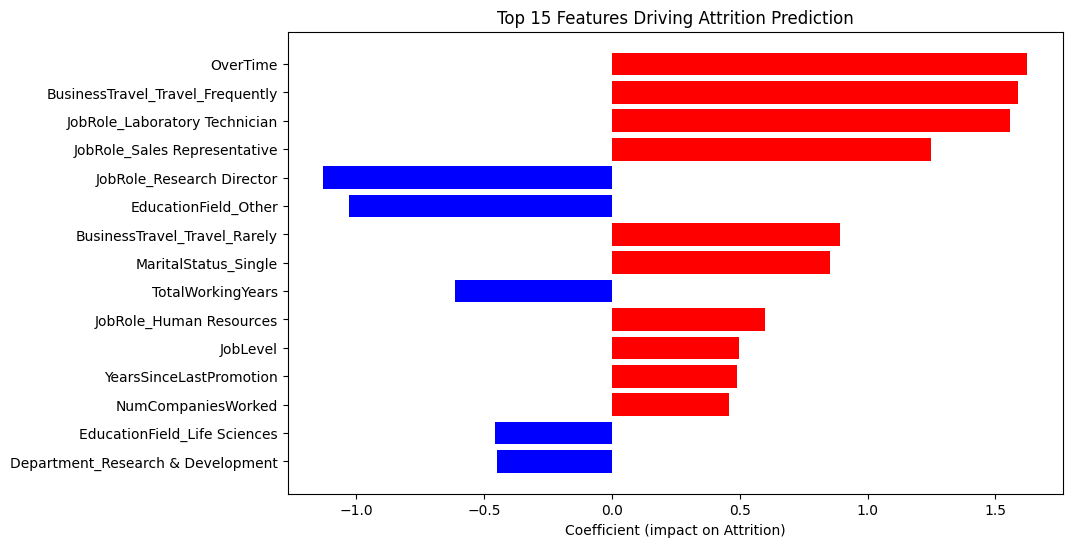

In [55]:
top_features = coefficients.head(15)

plt.figure(figsize=(10,6))
colors = ['red' if c > 0 else 'blue' for c in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.xlabel('Coefficient (impact on Attrition)')
plt.title('Top 15 Features Driving Attrition Prediction')
plt.gca().invert_yaxis()
plt.show()

OverTime emerged as the single strongest predictor of attrition, consistent with EDA findings. Frequent business travel, certain job roles (Lab Technician, Sales Rep), and being single also increased attrition risk. Conversely, greater total work experience and certain job roles (Research Director) were associated with lower attrition. Notably, MonthlyIncome does not appear directly in the top drivers despite its strong univariate relationship with attrition seen in EDA — likely because its effect is distributed across correlated features like JobLevel and TotalWorkingYears."

In [56]:
import pickle

In [57]:
model_artifacts = {
    'model': log_reg,
    'scaler': scaler,
    'feature_columns': x_train_scaled.columns.tolist(),
    'threshold': 0.4,
    'numeric_cols': numeric_cols
}

with open('attrition_model.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

## Streamlit App — Default Value Reference

The values below (medians/modes from the training data) are used as background defaults for 
non-primary input fields in the deployed Streamlit application.

In [58]:
print(df[['DistanceFromHome','Education','NumCompaniesWorked','PerformanceRating',
          'MonthlyRate','DailyRate','HourlyRate','PercentSalaryHike','StockOptionLevel',
          'JobInvolvement','JobSatisfaction','EnvironmentSatisfaction',
          'RelationshipSatisfaction','WorkLifeBalance','YearsInCurrentRole',
          'YearsWithCurrManager','TrainingTimesLastYear']].median())

print(df[['Gender']].mode().iloc[0])

DistanceFromHome                7.0
Education                       3.0
NumCompaniesWorked              2.0
PerformanceRating               3.0
MonthlyRate                 14235.5
DailyRate                     802.0
HourlyRate                     66.0
PercentSalaryHike              14.0
StockOptionLevel                1.0
JobInvolvement                  3.0
JobSatisfaction                 3.0
EnvironmentSatisfaction         3.0
RelationshipSatisfaction        3.0
WorkLifeBalance                 3.0
YearsInCurrentRole              3.0
YearsWithCurrManager            3.0
TrainingTimesLastYear           3.0
dtype: float64
Gender    1
Name: 0, dtype: int64
